In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['text.usetex'] = True

In [2]:
alphas_c = np.loadtxt('alpha_c.csv', delimiter=',') # threshold for q_info > 0
alphas_e = np.loadtxt('alpha_e.csv', delimiter=',') # theshold for q at equilibrium
mmses_e = np.loadtxt('mmse_e.csv', delimiter=',')

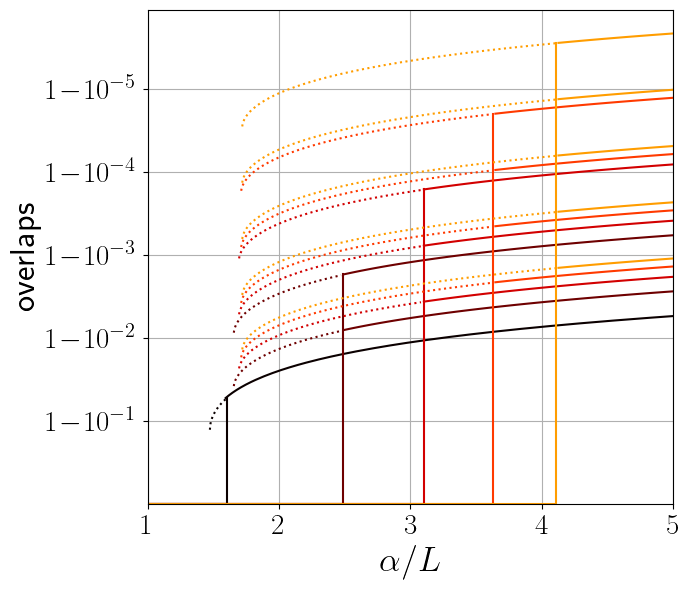

In [3]:
cmap = plt.get_cmap("hot")
colors = [cmap(i) for i in np.linspace(0, 0.6, 5)]

width, height = 7, 6
size = int(width*3)
fig, ax = plt.subplots(figsize=(width, height), tight_layout=True)

ax.tick_params(axis='both', labelsize=size)
ax.tick_params(axis='both', labelsize=size)
ax.set_xlabel(r'$\alpha/L$', fontsize=int(1.2*size))
ax.set_ylabel('overlaps', fontsize=int(1.2*size))

for L in range(1, 6):
    alphas = np.concatenate((np.linspace(1.4*L, 1.8*L, 201), np.linspace(1.8*L, 5*L, 101)))
    results = np.loadtxt(f'data/L_{L}.csv', delimiter=',') # mmse theory
    alpha_c, alpha_e = alphas_c[L-1], alphas_e[L-1]
    ind1 = (alpha_c <= alphas) & (alphas <= alpha_e) # dotted line
    ind2 = (alphas >= alpha_e)
    for i in range(1, len(results)):
        plt.plot(alphas[ind1]/L, -np.log10(1-results[i][ind1]), color=colors[L-1], linestyle='dotted')
        plt.plot(alphas[ind2]/L-0.01, -np.log10(1-results[i][ind2]), color=colors[L-1])
    val = -np.log10(1-results[1][ind2][0])
    plt.plot([0, alpha_e/L, alpha_e/L] ,[0, 0, val], color=colors[L-1])
            
ntick=6  
plt.yticks(range(1, ntick), [fr"$1\!-\!10^{{-{n}}}$" for n in range(1, ntick)]) 
plt.xlim(1, 5)
plt.ylim(0,)
plt.grid()
plt.savefig('deep-tanh-overlaps.pdf')

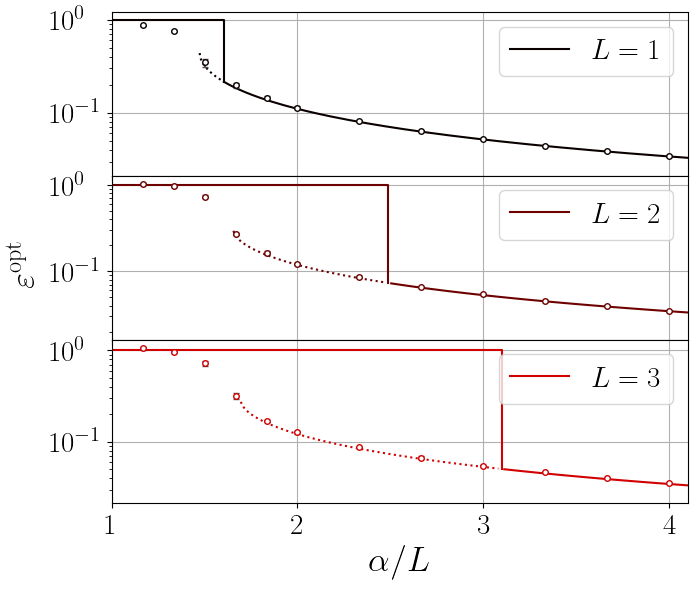

In [4]:
width, height = 7, 6
size = int(width*3)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(width, height), gridspec_kw={'hspace': 0}, tight_layout=True)
axes = (ax1, ax2, ax3)

ax1.set_xticks([1,2,3,4])
ax1.set_xlim(1, 4.1)
ax1.tick_params(axis='both', labelsize=size)
ax1.set_yscale('log')
ax1.grid()

ax2.set_xticks([1,2,3,4])
ax2.set_xlim(1, 4.1)
ax2.tick_params(axis='both', labelsize=size)
ax2.set_yscale('log')
ax2.grid()


ax3.set_xticks([1,2,3,4])
ax3.set_xlim(1, 4.1)
ax3.tick_params(axis='both', labelsize=size)
ax3.set_xlabel(r'$\alpha/L$', fontsize=int(1.2*size))
ax3.set_yscale('log')
ax3.grid()

Ls = np.arange(1,6)
for L, alpha_e, alpha_c, mmse_e, ax in zip(Ls[:3], alphas_e[:3], alphas_c[:3], mmses_e[:3], axes):
    alphas = np.concatenate((np.linspace(1.4*L, 1.8*L, 201), np.linspace(1.8*L, 5*L, 101)))
    
    ind1 = (alphas <= alpha_e)&(alphas >= alpha_c)
    ind2 = (alphas >= alpha_e)
    results = np.loadtxt(f'data/L_{L}.csv', delimiter=',')
    
    ax.plot(alphas[ind1]/L, results[0][ind1], color=colors[L-1], linestyle='dotted')
    ax.plot(alphas[ind2]/L, results[0][ind2], color=colors[L-1], label=fr'$L={L}$')
    ax.plot([1, alpha_e/L, alpha_e/L],[1, 1, mmse_e], color=colors[L-1])
    

    alphas_ex = np.array([1+1/6, 1+2/6, 1+3/6, 1+4/6, 1+5/6, 2, 2+1/3, 2+2/3, 3, 3+1/3, 3+2/3, 4])*L
    mmses_ex = np.loadtxt(f'deep_tanh_hmc_L_{L}.csv', delimiter=',')
    means_ex = np.mean(mmses_ex, axis=0)
    stds_ex = np.std(mmses_ex, axis=0)
    if ax == ax3:
        # remove stuck point
        ax.errorbar(np.delete(alphas_ex, [1, 2])/L, np.delete(means_ex, [1,2]), np.delete(stds_ex, [1,2]), fmt='o', markersize=4, markerfacecolor='white', markeredgecolor=colors[L-1], capsize=2, color=colors[L-1], ecolor='#505050')
        ax.legend(fontsize=size)
        alphas_d_30 = alphas_ex[1:3]
        mmses_d_30 = np.loadtxt(f'deep_tanh_hmc_L_{L}_d_30.csv', delimiter=',')
        # adding data point for d=30
        means_d_30 = np.mean(mmses_d_30, axis=0)
        stds_d_30 = np.std(mmses_d_30, axis=0)
        ax.errorbar(alphas_d_30/L, means_d_30, stds_d_30, fmt='o', markersize=4, markerfacecolor='white', markeredgecolor=colors[L-1], capsize=2, color=colors[L-1], ecolor='#505050')
    else:
        ax.errorbar(alphas_ex/L, means_ex, stds_ex, fmt='o', markersize=4, markerfacecolor='white', markeredgecolor=colors[L-1], capsize=2, color=colors[L-1], ecolor='#505050')
        
    ax.legend(fontsize=size, loc='upper right')

    for label in ax.get_yticklabels():
        label.set_ha('left')
        label.set_x(-0.09)

fig.tight_layout(rect=[0.05, 0, 1, 1])
fig.text(0.01, 0.55, r'$\varepsilon^{\rm opt}$', fontsize=int(1.2*size), va='center', rotation='vertical')
plt.savefig('deep-tanh-error.pdf')
